# WESM Price Prediction, Bonus: LSTM (with Hyperparameter Tuning)

## Setup and Loading

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")

Dataset Shape: (34535, 19)
Date Range: 2025-10-29 00:05:00 to 2026-02-26 00:00:00


---

## I. Why LSTM?

The feedforward neural network treats each 5-minute interval as an independent input. It only knows about the past through the three lag features (GWAP_Lag_1, GWAP_Lag_12, GWAP_Lag_288) that were manually engineered. An LSTM is different: it processes the data as a sequence and learns temporal patterns directly from the raw data.

This makes the LSTM a possibly better solution. If it performs significantly better, this would mean that the temporal structure of GWAP contains more information than the three lags we chose. If it performs similarly or worse, it suggests the lag features were already capturing the most important temporal signal (or the data we have may be insufficient).

**Note:** Removing the lag features from the LSTM input was tested and performed worse, confirming that GWAP_Lag_1 carries genuine signal that the model benefits from even with sequential processing. This is consistent with the Linear Regression coefficient analysis where GWAP_Lag_1 had the largest coefficient by far.

---

## II. Feature Selection

The same 16 base features as the other notebooks are used. Refer to the Linear Regression notebook for the full feature justification table.

One difference from the other notebooks: the LSTM receives sequences of these features over a lookback window rather than a single row at a time. The optimal lookback length is determined through hyperparameter tuning in Section VII.

In [95]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Features: {len(FEATURE_COLS)}")

Features: 16


---

## III. Train / Validation / Test Split

Same chronological 60/20/20 split as the other notebooks. The sequence construction is applied separately to each split after splitting. This prevents a sequence window from spanning the boundary between splits, which would mix training and validation data within the same input sample. This is not quite the same as label leakage but still an undesirable contamination of the splits.


In [96]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  20721 rows | 2025-10-29 to 2026-01-08
Val   :   6907 rows | 2026-01-08 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


---

## IV. Feature and Target Scaling

**Features** are standardized the same way as the other notebooks: the scaler is fit only on training data, then applied to validation and test.

**Target (GWAP)** is also standardized using a separate scaler. This is important for LSTM (and NN) since we don't want to explode the gradient descent process. Predictions are converted back to ₱/MWh before evaluation, so the metrics remain comparable with the other notebooks.

In [97]:
# Feature scaler
feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(train_df[FEATURE_COLS])
X_val_scaled   = feature_scaler.transform(val_df[FEATURE_COLS])
X_test_scaled  = feature_scaler.transform(test_df[FEATURE_COLS])

# Target scaler
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(train_df[[TARGET_COL]]).flatten()
y_val_scaled   = target_scaler.transform(val_df[[TARGET_COL]]).flatten()
y_test_scaled  = target_scaler.transform(test_df[[TARGET_COL]]).flatten()

# Raw targets for evaluation
y_train_raw = train_df[TARGET_COL].values
y_val_raw   = val_df[TARGET_COL].values
y_test_raw  = test_df[TARGET_COL].values

print(f"Scaled target - Train mean: {y_train_scaled.mean():.4f}, std: {y_train_scaled.std():.4f}")
print(f"Scaled target - Val   mean: {y_val_scaled.mean():.4f}, std: {y_val_scaled.std():.4f}")
print(f"Scaled target - Test  mean: {y_test_scaled.mean():.4f}, std: {y_test_scaled.std():.4f}")

Scaled target - Train mean: 0.0000, std: 1.0000
Scaled target - Val   mean: -0.2980, std: 0.8336
Scaled target - Test  mean: -0.1521, std: 0.5585


---

## V. Sequence Construction

LSTMs require input in the shape `(samples, timesteps, features)`. A sliding window of length `lookback` is used to build each sample: for each target value at time `t`, the input is the block of features from `t-lookback` to `t-1`. So if lookback = 24, the model sees the past 2 hours of data before making each prediction.

Since the lookback is a tunable hyperparameter, we defined the sequence builder as a function so we can use it for hypertuning.

In [98]:
def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

---

## VI. Tuning Framework

The `build_and_train` function below constructs, compiles, and trains an LSTM model for a given set of hyperparameters. It returns the trained model, training history, and wall-clock time. This is used by the tuning loop in Section VII.

The function supports the following tunable dimensions:

| Hyperparameter | What it controls | Values Tested |
|---|---|---|
| `lookback` | How many past timesteps the model sees | 12, 24, 48 |
| `lstm_units` | Number of neurons (hidden units) per LSTM layer | 32, 64, 128 |
| `num_layers` | How many LSTM layers are stacked | 1, 2 |
| `dropout` | Fraction of units randomly disabled during training | 0.1, 0.2, 0.3 |
| `learning_rate` | Step size for gradient descent | 0.001, 0.0005 |
| `batch_size` | Number of samples processed per training step |  64, 128 (Phase 3); 256 default for Phases 1-2  |

In [99]:
def build_and_train(lookback, lstm_units, num_layers, dropout, learning_rate, batch_size, verbose=0):

    # Build sequences for this lookback
    X_tr, y_tr = make_sequences(X_train_scaled, y_train_scaled, lookback)
    X_va, y_va = make_sequences(X_val_scaled,   y_val_scaled,   lookback)

    # Build model
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential()
    model.add(layers.Input(shape=(lookback, len(FEATURE_COLS))))

    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # only last LSTM returns single output
        model.add(layers.LSTM(lstm_units, return_sequences=return_seq))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse"
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    start = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stop],
        shuffle=False,
        verbose=verbose
    )
    elapsed = time.time() - start

    # Evaluate on validation set (in original scale)
    _, y_va_raw = make_sequences(X_val_scaled, y_val_raw, lookback)
    y_va_pred_scaled = model.predict(X_va, verbose=0).flatten()
    y_va_pred = target_scaler.inverse_transform(y_va_pred_scaled.reshape(-1, 1)).flatten()

    val_rmse = np.sqrt(mean_squared_error(y_va_raw, y_va_pred))
    val_mae  = mean_absolute_error(y_va_raw, y_va_pred)
    val_r2   = r2_score(y_va_raw, y_va_pred)

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_val_loss = min(history.history["val_loss"])

    return {
        "model": model,
        "history": history,
        "lookback": lookback,
        "lstm_units": lstm_units,
        "num_layers": num_layers,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "val_rmse": val_rmse,
        "val_mae": val_mae,
        "val_r2": val_r2,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "elapsed": elapsed
    }

---

## VII. Hyperparameter Tuning

A structured manual search is used instead of a full grid search (which would be 3 x 3 x 2 x 3 x 2 x 2 = 216 combinations). The search is organized in three phases:

1. **Phase 1, Architecture search**: change lookback, LSTM units, and number of layers while keeping dropout=0.2, lr=0.001, batch_size=256.
2. **Phase 2, Regularization search**: take the best architecture from Phase 1, then change dropout and learning rate.
3. **Phase 3, Batch size**: take the best config so far, then test batch sizes.

This narrows the search to roughly 15 configurations, each taking about 30 seconds to 2 minutes to train.

In [100]:
results = []

# Phase 1: Architecture (lookback x units x layers)
print("=" * 70)
print("PHASE 1: Architecture Search")
print("=" * 70)

phase1_configs = [
    # (lookback, units, layers)
    (12, 32, 1),
    (12, 64, 1),
    (12, 64, 2),
    (24, 32, 1),
    (24, 64, 1),
    (24, 64, 2),
    (24, 128, 1),
    (24, 128, 2),
    (48, 64, 1),
    (48, 64, 2),
    (48, 128, 1),
]

for i, (lb, units, nlayers) in enumerate(phase1_configs):
    tag = f"[{i+1}/{len(phase1_configs)}] lb={lb}, units={units}, layers={nlayers}"
    print(f"\n{tag}")

    r = build_and_train(
        lookback=lb, lstm_units=units, num_layers=nlayers,
        dropout=0.2, learning_rate=0.001, batch_size=256
    )
    results.append(r)

    print(f"  Val RMSE: {r['val_rmse']:.2f} | Val R²: {r['val_r2']:.4f} | "
          f"Epoch: {r['best_epoch']} | Time: {r['elapsed']:.0f}s")

# Find best Phase 1 config
phase1_best = min(results, key=lambda x: x["val_rmse"])
print(f"\n>>> Phase 1 Best: lb={phase1_best['lookback']}, units={phase1_best['lstm_units']}, "
      f"layers={phase1_best['num_layers']} | Val RMSE: {phase1_best['val_rmse']:.2f}, "
      f"R²: {phase1_best['val_r2']:.4f}")

PHASE 1: Architecture Search

[1/11] lb=12, units=32, layers=1
  Val RMSE: 1242.96 | Val R²: 0.7392 | Epoch: 52 | Time: 40s

[2/11] lb=12, units=64, layers=1
  Val RMSE: 1214.88 | Val R²: 0.7508 | Epoch: 29 | Time: 43s

[3/11] lb=12, units=64, layers=2
  Val RMSE: 1318.00 | Val R²: 0.7067 | Epoch: 14 | Time: 49s

[4/11] lb=24, units=32, layers=1
  Val RMSE: 1297.36 | Val R²: 0.7161 | Epoch: 41 | Time: 38s

[5/11] lb=24, units=64, layers=1
  Val RMSE: 1211.59 | Val R²: 0.7524 | Epoch: 47 | Time: 73s

[6/11] lb=24, units=64, layers=2
  Val RMSE: 1286.47 | Val R²: 0.7209 | Epoch: 24 | Time: 87s

[7/11] lb=24, units=128, layers=1
  Val RMSE: 1252.00 | Val R²: 0.7356 | Epoch: 13 | Time: 62s

[8/11] lb=24, units=128, layers=2
  Val RMSE: 1220.31 | Val R²: 0.7488 | Epoch: 23 | Time: 186s

[9/11] lb=48, units=64, layers=1
  Val RMSE: 1276.54 | Val R²: 0.7261 | Epoch: 24 | Time: 81s

[10/11] lb=48, units=64, layers=2
  Val RMSE: 1247.52 | Val R²: 0.7384 | Epoch: 29 | Time: 193s

[11/11] lb=48, 

In [101]:
# Phase 2: Regularization (dropout x learning rate)
print("=" * 70)
print("PHASE 2: Regularization Search")
print("=" * 70)

best_lb     = phase1_best["lookback"]
best_units  = phase1_best["lstm_units"]
best_layers = phase1_best["num_layers"]

phase2_configs = [
    # (dropout, learning_rate)
    (0.1, 0.001),
    (0.1, 0.0005),
    (0.2, 0.0005),
    (0.3, 0.001),
    (0.3, 0.0005),
]

for i, (drop, lr) in enumerate(phase2_configs):
    tag = f"[{i+1}/{len(phase2_configs)}] dropout={drop}, lr={lr}"
    print(f"\n{tag}")

    r = build_and_train(
        lookback=best_lb, lstm_units=best_units, num_layers=best_layers,
        dropout=drop, learning_rate=lr, batch_size=256
    )
    results.append(r)

    print(f"  Val RMSE: {r['val_rmse']:.2f} | Val R²: {r['val_r2']:.4f} | "
          f"Epoch: {r['best_epoch']} | Time: {r['elapsed']:.0f}s")

# Find best so far
phase2_best = min(results, key=lambda x: x["val_rmse"])
print(f"\n>>> Phase 2 Best: lb={phase2_best['lookback']}, units={phase2_best['lstm_units']}, "
      f"layers={phase2_best['num_layers']}, drop={phase2_best['dropout']}, "
      f"lr={phase2_best['learning_rate']} | Val RMSE: {phase2_best['val_rmse']:.2f}, "
      f"R²: {phase2_best['val_r2']:.4f}")

PHASE 2: Regularization Search

[1/5] dropout=0.1, lr=0.001
  Val RMSE: 1248.09 | Val R²: 0.7373 | Epoch: 30 | Time: 60s

[2/5] dropout=0.1, lr=0.0005
  Val RMSE: 1313.73 | Val R²: 0.7089 | Epoch: 49 | Time: 86s

[3/5] dropout=0.2, lr=0.0005
  Val RMSE: 1265.47 | Val R²: 0.7299 | Epoch: 37 | Time: 68s

[4/5] dropout=0.3, lr=0.001
  Val RMSE: 1226.30 | Val R²: 0.7464 | Epoch: 52 | Time: 89s

[5/5] dropout=0.3, lr=0.0005
  Val RMSE: 1257.33 | Val R²: 0.7334 | Epoch: 50 | Time: 87s

>>> Phase 2 Best: lb=24, units=64, layers=1, drop=0.2, lr=0.001 | Val RMSE: 1211.59, R²: 0.7524


In [102]:
# Phase 3: Batch size
print("=" * 70)
print("PHASE 3: Batch Size Search")
print("=" * 70)

best_drop = phase2_best["dropout"]
best_lr   = phase2_best["learning_rate"]

for bs in [64, 128]:
    tag = f"batch_size={bs}"
    print(f"\n{tag}")

    r = build_and_train(
        lookback=best_lb, lstm_units=best_units, num_layers=best_layers,
        dropout=best_drop, learning_rate=best_lr, batch_size=bs
    )
    results.append(r)

    print(f"  Val RMSE: {r['val_rmse']:.2f} | Val R²: {r['val_r2']:.4f} | "
          f"Epoch: {r['best_epoch']} | Time: {r['elapsed']:.0f}s")

# Overall best
overall_best = min(results, key=lambda x: x["val_rmse"])
print(f"\n{'=' * 70}")
print(f"OVERALL BEST CONFIG:")
print(f"  Lookback      : {overall_best['lookback']}")
print(f"  LSTM units    : {overall_best['lstm_units']}")
print(f"  Num layers    : {overall_best['num_layers']}")
print(f"  Dropout       : {overall_best['dropout']}")
print(f"  Learning rate : {overall_best['learning_rate']}")
print(f"  Batch size    : {overall_best['batch_size']}")
print(f"  Val RMSE      : {overall_best['val_rmse']:.4f}")
print(f"  Val MAE       : {overall_best['val_mae']:.4f}")
print(f"  Val R²        : {overall_best['val_r2']:.4f}")
print(f"  Best epoch    : {overall_best['best_epoch']}")
print(f"{'=' * 70}")

PHASE 3: Batch Size Search

batch_size=64
  Val RMSE: 1208.27 | Val R²: 0.7538 | Epoch: 16 | Time: 69s

batch_size=128
  Val RMSE: 1236.52 | Val R²: 0.7421 | Epoch: 21 | Time: 61s

OVERALL BEST CONFIG:
  Lookback      : 24
  LSTM units    : 64
  Num layers    : 1
  Dropout       : 0.2
  Learning rate : 0.001
  Batch size    : 64
  Val RMSE      : 1208.2723
  Val MAE       : 685.0047
  Val R²        : 0.7538
  Best epoch    : 16


### Tuning Results Summary

In [103]:
summary = pd.DataFrame([{
    "Lookback": r["lookback"],
    "Units": r["lstm_units"],
    "Layers": r["num_layers"],
    "Dropout": r["dropout"],
    "LR": r["learning_rate"],
    "Batch": r["batch_size"],
    "Val RMSE": round(r["val_rmse"], 2),
    "Val MAE": round(r["val_mae"], 2),
    "Val R²": round(r["val_r2"], 4),
    "Epoch": r["best_epoch"],
    "Time (s)": round(r["elapsed"], 0)
} for r in results])

summary = summary.sort_values("Val RMSE").reset_index(drop=True)
summary.index = summary.index + 1  # 1-indexed ranking
summary.index.name = "Rank"

print(summary.to_string())

      Lookback  Units  Layers  Dropout      LR  Batch  Val RMSE  Val MAE  Val R²  Epoch  Time (s)
Rank                                                                                             
1           24     64       1      0.2  0.0010     64   1208.27   685.00  0.7538     16      69.0
2           24     64       1      0.2  0.0010    256   1211.59   696.54  0.7524     47      73.0
3           12     64       1      0.2  0.0010    256   1214.88   715.04  0.7508     29      43.0
4           48    128       1      0.2  0.0010    256   1219.67   701.59  0.7499     11     134.0
5           24    128       2      0.2  0.0010    256   1220.31   712.04  0.7488     23     186.0
6           24     64       1      0.3  0.0010    256   1226.30   719.73  0.7464     52      89.0
7           24     64       1      0.2  0.0010    128   1236.52   740.15  0.7421     21      61.0
8           12     32       1      0.2  0.0010    256   1242.96   678.05  0.7392     52      40.0
9           48     6

---

## VIII. Final Model (Best Configuration)

The best hyperparameters from the tuning search are used to retrain a final model. This model is then evaluated on the separated test set.

In [104]:
# Retrain best config
print("Retraining best configuration...")
print(f"  Lookback={overall_best['lookback']}, Units={overall_best['lstm_units']}, "
      f"Layers={overall_best['num_layers']}, Dropout={overall_best['dropout']}, "
      f"LR={overall_best['learning_rate']}, Batch={overall_best['batch_size']}")

BEST_LOOKBACK = overall_best["lookback"]

final_result = build_and_train(
    lookback=overall_best["lookback"],
    lstm_units=overall_best["lstm_units"],
    num_layers=overall_best["num_layers"],
    dropout=overall_best["dropout"],
    learning_rate=overall_best["learning_rate"],
    batch_size=overall_best["batch_size"],
    verbose=1
)

final_model = final_result["model"]
final_history = final_result["history"]

Retraining best configuration...
  Lookback=24, Units=64, Layers=1, Dropout=0.2, LR=0.001, Batch=64
Epoch 1/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4922 - val_loss: 0.2849
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3274 - val_loss: 0.2393
Epoch 3/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2903 - val_loss: 0.2235
Epoch 4/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2770 - val_loss: 0.2135
Epoch 5/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2641 - val_loss: 0.2044
Epoch 6/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2652 - val_loss: 0.1974
Epoch 7/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2533 - val_loss: 0.1841
Epoch 8/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2573 - val_loss: 0.1865
Epoch 9/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2495 - val_loss: 0.1792
Epoch 10/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2429 - val_loss: 0.1760
Epoch 11/100
324/324 ━━━━━━━━

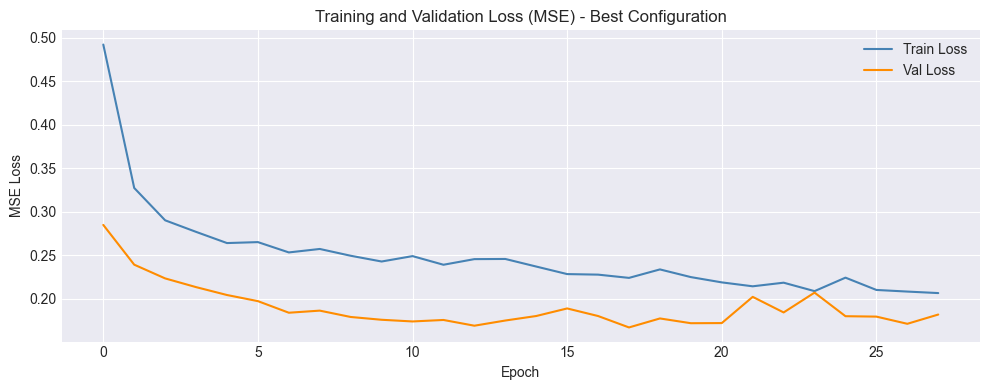

In [105]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(final_history.history["loss"],     label="Train Loss", color="steelblue")
ax.plot(final_history.history["val_loss"], label="Val Loss",   color="darkorange")
ax.set_title("Training and Validation Loss (MSE) - Best Configuration")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

---

## IX. Test Set Evaluation

The final model is evaluated on the test set using the same metrics as all other notebooks: RMSE, MAE, and R². Predictions are inverse-transformed from the scaled space back to ₱/MWh.

In [106]:
# Build test sequences with the best lookback
X_test_seq, y_test_seq_scaled = make_sequences(X_test_scaled, y_test_scaled, BEST_LOOKBACK)
_, y_test_seq_raw = make_sequences(X_test_scaled, y_test_raw, BEST_LOOKBACK)

# Predict and inverse-transform
y_test_pred_scaled = final_model.predict(X_test_seq).flatten()
y_test_pred = target_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test_seq_raw, y_test_pred))
mae  = mean_absolute_error(y_test_seq_raw, y_test_pred)
r2   = r2_score(y_test_seq_raw, y_test_pred)

print(f"{'Metric':<8} | {'Value':>12}")
print("-" * 24)
print(f"{'RMSE':<8} | {rmse:>10.4f} ₱/MWh")
print(f"{'MAE':<8} | {mae:>10.4f} ₱/MWh")
print(f"{'R²':<8} | {r2:>12.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Metric   |        Value
------------------------
RMSE     |  1185.7483 ₱/MWh
MAE      |   748.7929 ₱/MWh
R²       |       0.4727


In [107]:
lr_test_rmse   = 934.4698
lr_test_mae    = 459.4758
lr_test_r2     = 0.6714

comparison = pd.DataFrame({
    "Model"    : ["Linear Regression", "Polynomial Ridge", "Poly Elastic Net", "LSTM (bonus)"],
    "Test RMSE": [lr_test_rmse, 972.1944, 930.0893, rmse],
    "Test MAE" : [lr_test_mae,  552.9226, 471.7096, mae],
    "Test R²"  : [lr_test_r2,   0.6444,   0.6745,   r2]
})

print(comparison.to_string(index=False))

            Model   Test RMSE   Test MAE  Test R²
Linear Regression  934.469800 459.475800 0.671400
 Polynomial Ridge  972.194400 552.922600 0.644400
 Poly Elastic Net  930.089300 471.709600 0.674500
     LSTM (bonus) 1185.748282 748.792888 0.472702


---

## X. Visualizations

### Actual vs. Predicted (Time Series)

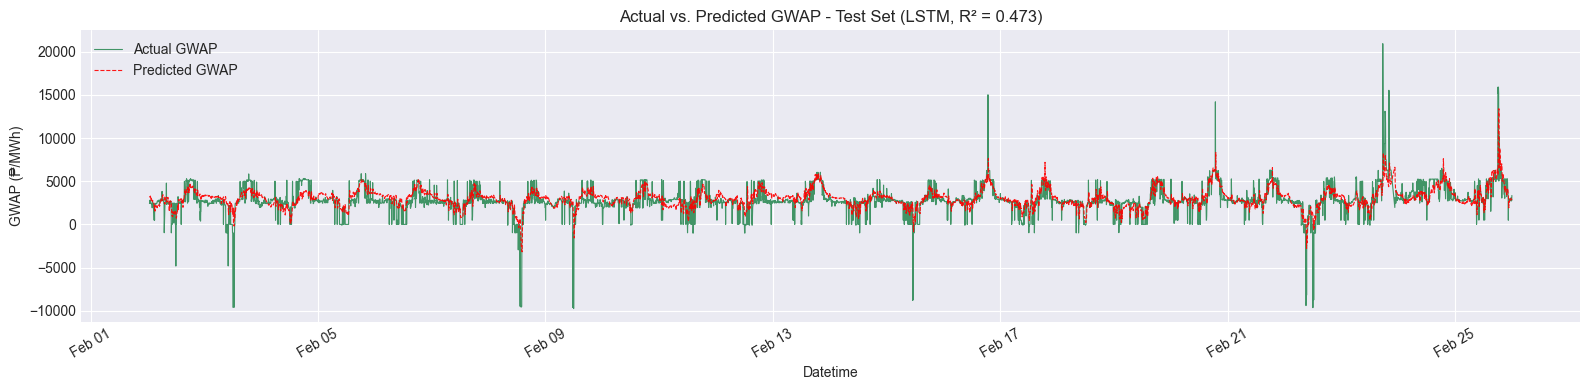

In [108]:
fig, ax = plt.subplots(figsize=(16, 4))

test_datetimes = test_df["datetime"].values[BEST_LOOKBACK:]

ax.plot(test_datetimes, y_test_seq_raw, color="seagreen",   linewidth=0.8, alpha=0.9, label="Actual GWAP")
ax.plot(test_datetimes, y_test_pred,    color="red",        linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
ax.set_title(f"Actual vs. Predicted GWAP - Test Set (LSTM, R² = {round(r2, 3)})")
ax.set_ylabel("GWAP (₱/MWh)")
ax.set_xlabel("Datetime")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Actual vs. Predicted, Scatter Plot

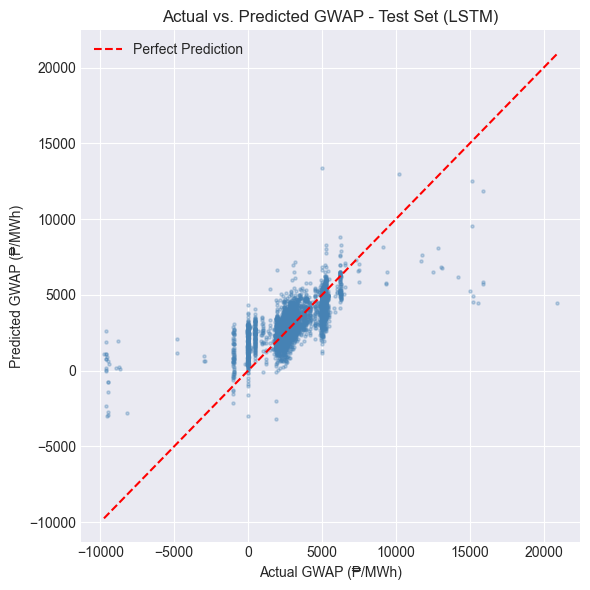

In [109]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test_seq_raw, y_test_pred, alpha=0.3, s=5, color="steelblue")

lims = [min(y_test_seq_raw.min(), y_test_pred.min()), max(y_test_seq_raw.max(), y_test_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_title("Actual vs. Predicted GWAP - Test Set (LSTM)")
ax.set_xlabel("Actual GWAP (₱/MWh)")
ax.set_ylabel("Predicted GWAP (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

### Residual Plot

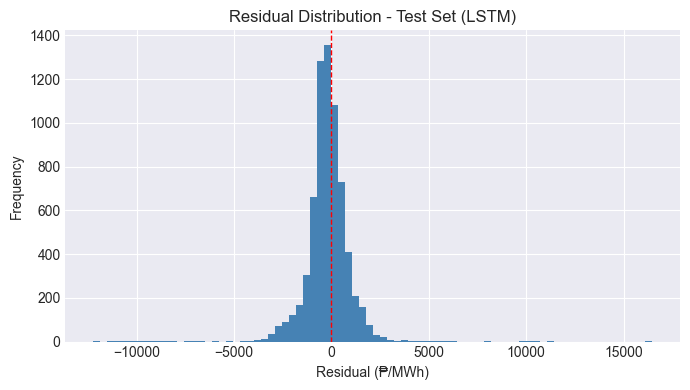

Mean Residual : -225.4461  (close to 0 = unbiased)
Std Residual  : 1164.1190
Max Residual  : 16461.0367
Min Residual  : -12219.0696


In [110]:
residuals = y_test_seq_raw - y_test_pred

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(residuals, bins=80, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Residual Distribution - Test Set (LSTM)")
ax.set_xlabel("Residual (₱/MWh)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"Std Residual  : {residuals.std():.4f}")
print(f"Max Residual  : {residuals.max():.4f}")
print(f"Min Residual  : {residuals.min():.4f}")

---

## XI. Why the Baseline LSTM Underperforms

The best configuration this run was lookback=24, 64 units, 1 layer (dropout=0.2, lr=0.001, batch=64). As noted in Section VII, the exact winning configuration varies between runs due to non-determinism in TensorFlow even with fixed seeds, but the top configurations are always very close in val RMSE and the conclusion does not change.

Regardless of configuration, the LSTM could not beat linear regression. The root cause is **GWAP_Lag_1**, which has a coefficient of 2,260 in the Linear Regression notebook — nearly 8x the next largest feature. The prediction task reduces to "next price ≈ last price + small corrections," a fundamentally linear relationship. Linear regression finds the best solution in one step using OLS. The LSTM must arrive at the same answer through thousands of gradient updates — a harder path to the same destination.

To address this, the following two sections test alternative target formulations:

- **Approach A (Residual Stacking):** let linear regression handle the baseline, train the LSTM to predict only the errors.
- **Approach B (Price Change):** predict ΔGWAP = GWAP(t) - GWAP(t-1) instead of the raw level.

Both approaches use the best hyperparameters from tuning so the comparison isolates the target formulation, not the architecture.

---

## XII. Approach A, Residual Stacking

In residual stacking, a simple model handles the baseline prediction and a second model learns to correct its mistakes. Linear regression serves as the base model since it is the best-performing classical model, and the LSTM is trained to predict the residuals (actual - linear prediction).

The final prediction is: `GWAP_pred = LR_pred + LSTM_correction`

Instead of asking the LSTM to predict everything from scratch, we only ask it to learn the patterns in what the linear model gets wrong: price spikes, demand-supply imbalances, and other nonlinear behavior that a straight line cannot capture.

**Note:** The LR base model is trained on train+val (same as `lr_final` in the Linear Regression notebook) so the test evaluation is fully consistent. Residuals for training the LSTM are computed using a train-only LR model to avoid leaking validation labels.

### Step 1: Train Linear Regression Base Model

In [111]:
from sklearn.linear_model import LinearRegression

# Train LR base on train+val (same as lr_final in NB3) for a fair final evaluation
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval_raw    = np.concatenate([y_train_raw, y_val_raw])

lr_base = LinearRegression()
lr_base.fit(X_trainval_scaled, y_trainval_raw)

# For residual computation we need train-only predictions
# so we also keep a train-only model
lr_base_train_only = LinearRegression()
lr_base_train_only.fit(X_train_scaled, y_train_raw)

# Residuals are computed using the train-only model
# (validation residuals also from train-only, since val was not used to fit it)
lr_pred_train = lr_base_train_only.predict(X_train_scaled)
lr_pred_val   = lr_base_train_only.predict(X_val_scaled)

# Final test predictions use the train+val model
lr_pred_test  = lr_base.predict(X_test_scaled)

lr_base_rmse = np.sqrt(mean_squared_error(y_test_raw, lr_pred_test))
lr_base_r2   = r2_score(y_test_raw, lr_pred_test)
print(f"LR base model (train+val) - Test RMSE: {lr_base_rmse:.4f}, R²: {lr_base_r2:.4f}")


LR base model (train+val) - Test RMSE: 934.4698, R²: 0.6714


### Step 2: Compute and Scale Residuals

In [112]:
# Residuals = what the LR got wrong
resid_train = y_train_raw - lr_pred_train
resid_val   = y_val_raw   - lr_pred_val
resid_test  = y_test_raw  - lr_pred_test

# Scale residuals for LSTM training
resid_scaler = StandardScaler()
resid_train_scaled = resid_scaler.fit_transform(resid_train.reshape(-1, 1)).flatten()
resid_val_scaled   = resid_scaler.transform(resid_val.reshape(-1, 1)).flatten()
resid_test_scaled  = resid_scaler.transform(resid_test.reshape(-1, 1)).flatten()

print(f"Residual stats (train):")
print(f"  Raw   - mean: {resid_train.mean():.2f}, std: {resid_train.std():.2f}")
print(f"  Scaled - mean: {resid_train_scaled.mean():.4f}, std: {resid_train_scaled.std():.4f}")

Residual stats (train):
  Raw   - mean: -0.00, std: 1241.38
  Scaled - mean: 0.0000, std: 1.0000


### Step 3: Train LSTM on Residuals

In [113]:
# Build sequences: same features, but target is now the LR residual
X_tr_A, y_tr_A = make_sequences(X_train_scaled, resid_train_scaled, BEST_LOOKBACK)
X_va_A, y_va_A = make_sequences(X_val_scaled,   resid_val_scaled,   BEST_LOOKBACK)
X_te_A, y_te_A = make_sequences(X_test_scaled,  resid_test_scaled,  BEST_LOOKBACK)

# Use best hyperparameters from tuning
tf.random.set_seed(42)
np.random.seed(42)
model_A = keras.Sequential([
    layers.Input(shape=(BEST_LOOKBACK, len(FEATURE_COLS))),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_A.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")

early_stop_A = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history_A = model_A.fit(
    X_tr_A, y_tr_A,
    validation_data=(X_va_A, y_va_A),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_A],
    shuffle=False,
    verbose=1
)

Epoch 1/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.0164 - val_loss: 0.7016
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9814 - val_loss: 0.6930
Epoch 3/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9724 - val_loss: 0.6889
Epoch 4/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9657 - val_loss: 0.6869
Epoch 5/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9609 - val_loss: 0.6876
Epoch 6/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9534 - val_loss: 0.6852
Epoch 7/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9541 - val_loss: 0.6851
Epoch 8/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9455 - val_loss: 0.6852
Epoch 9/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9443 - val_loss: 0.6888
Epoch 10/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9401 - val_loss: 0.6849
Epoch 11/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9358 - val_loss: 0.6860
Epoch 12/100
324/324 ━━━━━━━━━━━━━━━━━━━━

### Step 4: Evaluate, Residual Stacking

In [114]:
# LSTM predicts the residual (scaled), inverse-transform to get correction in PHP/MWh
lstm_correction_scaled = model_A.predict(X_te_A).flatten()
lstm_correction = resid_scaler.inverse_transform(lstm_correction_scaled.reshape(-1, 1)).flatten()

# LR predictions aligned with sequence indices (skip first BEST_LOOKBACK rows)
lr_pred_test_aligned = lr_pred_test[BEST_LOOKBACK:]

# Final stacked prediction
y_pred_A = lr_pred_test_aligned + lstm_correction

# Actual values aligned with sequences
y_actual_A = y_test_raw[BEST_LOOKBACK:]

rmse_A = np.sqrt(mean_squared_error(y_actual_A, y_pred_A))
mae_A  = mean_absolute_error(y_actual_A, y_pred_A)
r2_A   = r2_score(y_actual_A, y_pred_A)

print(f"{'Metric':<8} | {'Value':>12}")
print("-" * 24)
print(f"{'RMSE':<8} | {rmse_A:>10.4f} ₱/MWh")
print(f"{'MAE':<8} | {mae_A:>10.4f} ₱/MWh")
print(f"{'R²':<8} | {r2_A:>12.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metric   |        Value
------------------------
RMSE     |   936.2780 ₱/MWh
MAE      |   478.4975 ₱/MWh
R²       |       0.6712


Approach A brings the LSTM from RMSE ₱1,186 down to ₱936, essentially matching linear regression's ₱934 and R² 0.671. This is a very large improvement. The stacked model reaches near-parity with the linear baseline it is built on.

The LR base model (train+val) achieves ₱934 on test — identical to NB3's `lr_final`. The LSTM correction adds marginal value on some intervals but introduces small new errors on others. The net result is near-parity: the residual stacking confirms that the LSTM can learn something from the LR errors, but not enough to consistently surpass the base model.

### Visualizations - Residual Stacking

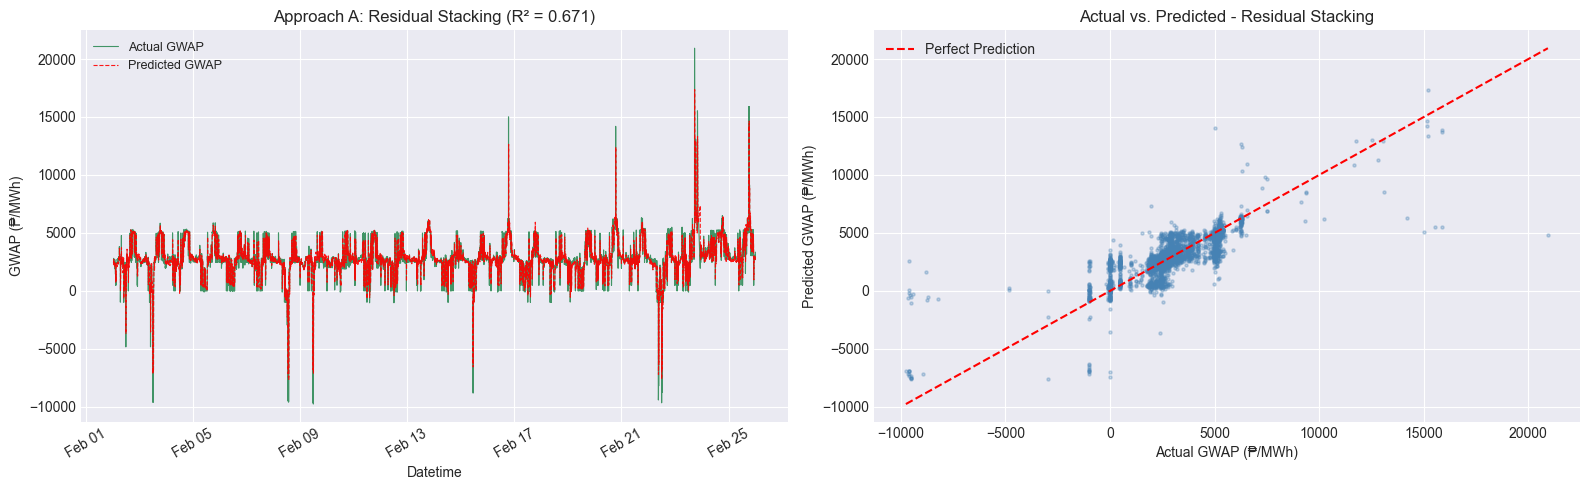

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

test_dt_A = test_df["datetime"].values[BEST_LOOKBACK:]

# Time series
axes[0].plot(test_dt_A, y_actual_A, color="seagreen", linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[0].plot(test_dt_A, y_pred_A,   color="red",      linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[0].set_title(f"Approach A: Residual Stacking (R² = {round(r2_A, 3)})")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].set_xlabel("Datetime")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].tick_params(axis='x', rotation=30)

# Scatter
axes[1].scatter(y_actual_A, y_pred_A, alpha=0.3, s=5, color="steelblue")
lims = [min(y_actual_A.min(), y_pred_A.min()), max(y_actual_A.max(), y_pred_A.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
axes[1].set_title("Actual vs. Predicted - Residual Stacking")
axes[1].set_xlabel("Actual GWAP (₱/MWh)")
axes[1].set_ylabel("Predicted GWAP (₱/MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## XIII. Approach B, Price Change (ΔGWAP)

Instead of predicting the raw GWAP level, this approach reframes the target as the 5-minute price change:

`ΔGWAP(t) = GWAP(t) − GWAP(t−1)`

Since GWAP_Lag_1 is already a column in the dataset, this is equivalent to `GWAP − GWAP_Lag_1`. Predicting the change strips out the dominant "next price ≈ last price" relationship and forces the LSTM to focus on what actually moves the price at each interval. The final prediction reconstructs the level as:

`GWAP_pred(t) = GWAP_Lag_1(t) + predicted_ΔGWAP(t)`

If the LSTM can learn meaningful patterns in price movements (e.g., demand ramps before a spike, or supply shifts causing drops), this formulation gives it a better shot at expressing that.

### Step 1: Compute and Scale Price Changes

In [116]:
# Delta = GWAP(t) - GWAP(t-1), which is GWAP - GWAP_Lag_1
delta_train = train_df[TARGET_COL].values - train_df["GWAP_Lag_1"].values
delta_val   = val_df[TARGET_COL].values   - val_df["GWAP_Lag_1"].values
delta_test  = test_df[TARGET_COL].values  - test_df["GWAP_Lag_1"].values

# Scale
delta_scaler = StandardScaler()
delta_train_scaled = delta_scaler.fit_transform(delta_train.reshape(-1, 1)).flatten()
delta_val_scaled   = delta_scaler.transform(delta_val.reshape(-1, 1)).flatten()
delta_test_scaled  = delta_scaler.transform(delta_test.reshape(-1, 1)).flatten()

print(f"ΔGWAP stats (train):")
print(f"  Raw    - mean: {delta_train.mean():.2f}, std: {delta_train.std():.2f}")
print(f"  Scaled - mean: {delta_train_scaled.mean():.4f}, std: {delta_train_scaled.std():.4f}")

ΔGWAP stats (train):
  Raw    - mean: 0.11, std: 1323.47
  Scaled - mean: 0.0000, std: 1.0000


### Step 2: Train LSTM on Price Changes

In [117]:
# Build sequences: same features, target is now ΔGWAP
X_tr_B, y_tr_B = make_sequences(X_train_scaled, delta_train_scaled, BEST_LOOKBACK)
X_va_B, y_va_B = make_sequences(X_val_scaled,   delta_val_scaled,   BEST_LOOKBACK)
X_te_B, y_te_B = make_sequences(X_test_scaled,  delta_test_scaled,  BEST_LOOKBACK)

# Same architecture and hyperparameters
tf.random.set_seed(42)
np.random.seed(42)
model_B = keras.Sequential([
    layers.Input(shape=(BEST_LOOKBACK, len(FEATURE_COLS))),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_B.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")

early_stop_B = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history_B = model_B.fit(
    X_tr_B, y_tr_B,
    validation_data=(X_va_B, y_va_B),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_B],
    shuffle=False,
    verbose=1
)

Epoch 1/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.0323 - val_loss: 0.7289
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0020 - val_loss: 0.7232
Epoch 3/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9939 - val_loss: 0.7159
Epoch 4/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9861 - val_loss: 0.7149
Epoch 5/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9815 - val_loss: 0.7132
Epoch 6/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9796 - val_loss: 0.7119
Epoch 7/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9743 - val_loss: 0.7114
Epoch 8/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9709 - val_loss: 0.7094
Epoch 9/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9681 - val_loss: 0.7092
Epoch 10/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9636 - val_loss: 0.7089
Epoch 11/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9622 - val_loss: 0.7089
Epoch 12/100
324/324 ━━━━━━━━━━━━━━━━━━━━

### Step 3: Evaluate, Price Change

In [118]:
# LSTM predicts ΔGWAP (scaled), inverse-transform
delta_pred_scaled = model_B.predict(X_te_B).flatten()
delta_pred = delta_scaler.inverse_transform(delta_pred_scaled.reshape(-1, 1)).flatten()

# Reconstruct GWAP: GWAP_Lag_1(t) + predicted delta(t)
# GWAP_Lag_1 for the test rows aligned with sequences (skip first BEST_LOOKBACK)
lag1_test_aligned = test_df["GWAP_Lag_1"].values[BEST_LOOKBACK:]

y_pred_B = lag1_test_aligned + delta_pred

# Actual values
y_actual_B = y_test_raw[BEST_LOOKBACK:]

rmse_B = np.sqrt(mean_squared_error(y_actual_B, y_pred_B))
mae_B  = mean_absolute_error(y_actual_B, y_pred_B)
r2_B   = r2_score(y_actual_B, y_pred_B)

print(f"{'Metric':<8} | {'Value':>12}")
print("-" * 24)
print(f"{'RMSE':<8} | {rmse_B:>10.4f} ₱/MWh")
print(f"{'MAE':<8} | {mae_B:>10.4f} ₱/MWh")
print(f"{'R²':<8} | {r2_B:>12.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metric   |        Value
------------------------
RMSE     |  1025.1278 ₱/MWh
MAE      |   562.5142 ₱/MWh
R²       |       0.6059


Approach B improves over the baseline LSTM (RMSE ₱1,025 vs ₱1,186, R² 0.606 vs 0.473) but falls short of both Approach A and the linear models. The 5-minute price change is inherently very noisy (std = ₱1,241), making it a difficult target to learn from.

Approach B also underperforms Approach A because of how errors carry through. In Approach A, the LR base provides a stable anchor for every prediction. In Approach B, the LSTM bears full responsibility for the change prediction and any mistake feeds directly into the reconstructed price level with no safety net.

### Visualizations - Price Change

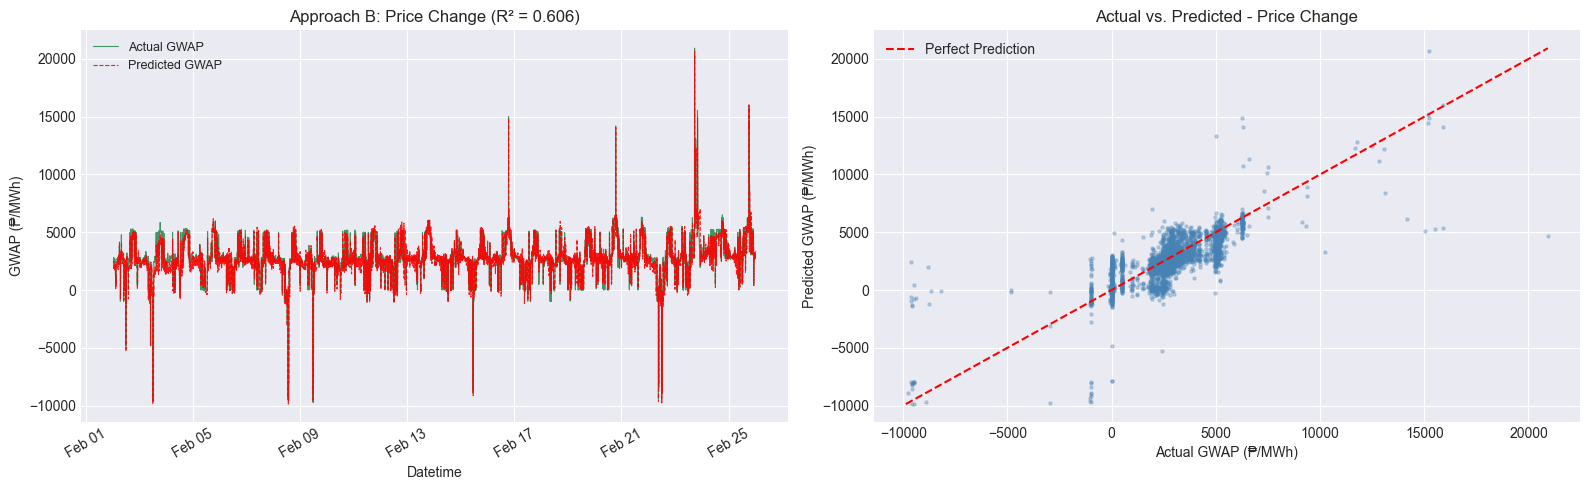

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

test_dt_B = test_df["datetime"].values[BEST_LOOKBACK:]

# Time series
axes[0].plot(test_dt_B, y_actual_B, color="seagreen", linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[0].plot(test_dt_B, y_pred_B,   color="red",      linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[0].set_title(f"Approach B: Price Change (R² = {round(r2_B, 3)})")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].set_xlabel("Datetime")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].tick_params(axis='x', rotation=30)

# Scatter
axes[1].scatter(y_actual_B, y_pred_B, alpha=0.3, s=5, color="steelblue")
lims = [min(y_actual_B.min(), y_pred_B.min()), max(y_actual_B.max(), y_pred_B.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
axes[1].set_title("Actual vs. Predicted - Price Change")
axes[1].set_xlabel("Actual GWAP (₱/MWh)")
axes[1].set_ylabel("Predicted GWAP (₱/MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## XIV. Final Comparison

Test set performance across all model variants. The classical models are included for reference.

In [120]:
final_comparison = pd.DataFrame({
    "Model"    : [
        "Linear Regression",
        "Polynomial Ridge",
        "Poly Elastic Net",
        "LSTM - Baseline",
        "LSTM - Residual Stacking (A)",
        "LSTM - Price Change (B)"
    ],
    "Test RMSE": [934.4698, 972.1944, 930.0893, baseline_rmse, rmse_A, rmse_B],
    "Test MAE" : [459.4758, 552.9226, 471.7096, baseline_mae, mae_A, mae_B],
    "Test R²"  : [0.6714,   0.6444,   0.6745,   baseline_r2,  r2_A,  r2_B]
})

print("Test Set Performance - All Models")
print()
print(final_comparison.to_string(index=False))


Test Set Performance - All Models

                       Model   Test RMSE   Test MAE  Test R²
           Linear Regression  934.469800 459.475800 0.671400
            Polynomial Ridge  972.194400 552.922600 0.644400
            Poly Elastic Net  930.089300 471.709600 0.674500
             LSTM - Baseline 1131.755155 679.637745 0.519630
LSTM - Residual Stacking (A)  936.277958 478.497522 0.671239
     LSTM - Price Change (B) 1025.127797 562.514225 0.605881


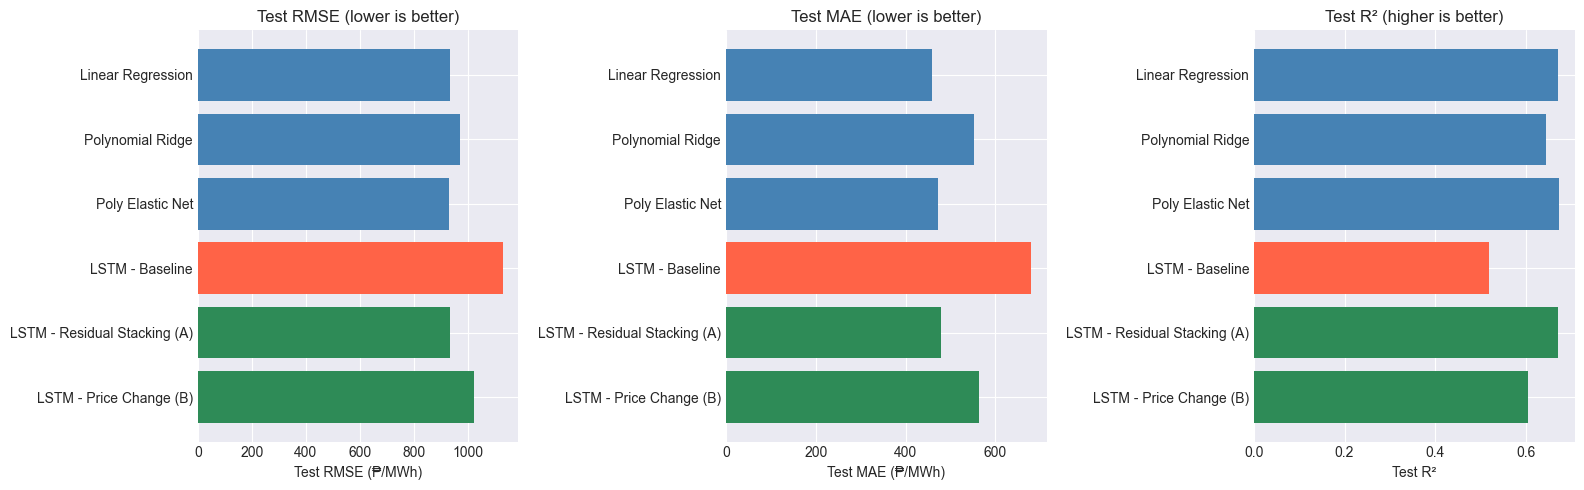

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = final_comparison["Model"]
colors = ["steelblue", "steelblue", "steelblue", "tomato", "seagreen", "seagreen"]

# RMSE
axes[0].barh(models, final_comparison["Test RMSE"], color=colors)
axes[0].set_xlabel("Test RMSE (₱/MWh)")
axes[0].set_title("Test RMSE (lower is better)")
axes[0].invert_yaxis()

# MAE
axes[1].barh(models, final_comparison["Test MAE"], color=colors)
axes[1].set_xlabel("Test MAE (₱/MWh)")
axes[1].set_title("Test MAE (lower is better)")
axes[1].invert_yaxis()

# R²
axes[2].barh(models, final_comparison["Test R²"], color=colors)
axes[2].set_xlabel("Test R²")
axes[2].set_title("Test R² (higher is better)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


---

## XV. LSTM as a Classifier


The regression experiments show the LSTM struggles to outperform linear regression because the task is dominated by GWAP_Lag_1. However, the Multiclass Logistic Regression notebook showed a different picture for classification: the dominant features were energy demand and supply, not the lags. The classification task asks whether a spike event is occurring, not what the exact price level is. LSTMs are potentially better suited to this — they can learn sequences of market conditions leading up to a spike rather than just seeing a single snapshot.

This section trains an LSTM classifier using the same three classes as the Multiclass Logistic Regression notebook:
- **0 - Normal**: GWAP in (0, 5,000]
- **1 - Negative**: GWAP <= 0
- **2 - Positive Spike**: GWAP > 5,000

The best architecture from regression tuning is reused (lookback=24, 64 units, 1 layer) so the comparison isolates the effect of the task framing, not the architecture.

In [122]:
from sklearn.metrics import classification_report, roc_auc_score

# Create class labels
def assign_class(gwap):
    if gwap <= 0:
        return 1  # Negative
    elif gwap > 5000:
        return 2  # Positive Spike
    else:
        return 0  # Normal

y_train_cls = train_df['GWAP'].apply(assign_class).values
y_val_cls   = val_df['GWAP'].apply(assign_class).values
y_test_cls  = test_df['GWAP'].apply(assign_class).values

# Build sequences (reuse existing feature-scaled arrays and make_sequences)
X_tr_cls, y_tr_cls = make_sequences(X_train_scaled, y_train_cls, BEST_LOOKBACK)
X_va_cls, y_va_cls = make_sequences(X_val_scaled,   y_val_cls,   BEST_LOOKBACK)
X_te_cls, y_te_cls = make_sequences(X_test_scaled,  y_test_cls,  BEST_LOOKBACK)

print(f"Train sequences: {X_tr_cls.shape}")
print(f"Class distribution (test): {dict(zip(*np.unique(y_te_cls, return_counts=True)))}")


Train sequences: (20697, 24, 16)
Class distribution (test): {np.int64(0): np.int64(5606), np.int64(1): np.int64(459), np.int64(2): np.int64(818)}


In [123]:
# Build LSTM classifier
tf.random.set_seed(42)
np.random.seed(42)

lstm_clf = keras.Sequential([
    layers.Input(shape=(BEST_LOOKBACK, len(FEATURE_COLS))),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.1),
    layers.Dense(3, activation='softmax')  # 3 classes, softmax output
])

lstm_clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_clf = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_clf = lstm_clf.fit(
    X_tr_cls, y_tr_cls,
    validation_data=(X_va_cls, y_va_cls),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_clf],
    shuffle=False,
    verbose=1
)

print(f"\nStopped at epoch {len(history_clf.history['loss'])}")


Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7008 - loss: 0.7767 - val_accuracy: 0.8229 - val_loss: 0.5736
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8551 - loss: 0.4638 - val_accuracy: 0.8344 - val_loss: 0.4568
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8654 - loss: 0.3972 - val_accuracy: 0.8289 - val_loss: 0.4227
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8697 - loss: 0.3667 - val_accuracy: 0.8396 - val_loss: 0.3912
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8759 - loss: 0.3440 - val_accuracy: 0.8520 - val_loss: 0.3718
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8798 - loss: 0.3298 - val_accuracy: 0.8559 - val_loss: 0.3597
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8839 - loss: 0.3178 - val_accuracy: 0.8631 - val_loss: 0.3524
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8887 - loss: 0.3076 - val_accuracy: 0.8676 - 

In [124]:
# Evaluate on test set
CLASS_NAMES = ['Normal', 'Negative', 'Pos. Spike']

y_pred_cls  = lstm_clf.predict(X_te_cls).argmax(axis=1)
y_prob_cls  = lstm_clf.predict(X_te_cls)

report = classification_report(y_te_cls, y_pred_cls, target_names=CLASS_NAMES, output_dict=True)
auc    = roc_auc_score(y_te_cls, y_prob_cls, multi_class='ovr', average='macro')

print(classification_report(y_te_cls, y_pred_cls, target_names=CLASS_NAMES))
print(f"Macro F1    : {report['macro avg']['f1-score']:.4f}")
print(f"ROC-AUC     : {auc:.4f}")

# Comparison with logistic regression classifier
lr_macro_f1 = 0.7636
lr_auc      = 0.9471
print(f"\nComparison with Multiclass Logistic Regression:")
print(f"{'Model':<30} | {'Macro F1':>10} | {'ROC-AUC':>10}")
print("-" * 55)
print(f"{'Logistic Regression':<30} | {lr_macro_f1:>10.4f} | {lr_auc:>10.4f}")
print(f"{'LSTM Classifier':<30} | {report['macro avg']['f1-score']:>10.4f} | {auc:>10.4f}")


216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

      Normal       0.89      0.94      0.91      5606
    Negative       0.59      0.08      0.14       459
  Pos. Spike       0.66      0.71      0.68       818

    accuracy                           0.86      6883
   macro avg       0.71      0.58      0.58      6883
weighted avg       0.84      0.86      0.84      6883

Macro F1    : 0.5783
ROC-AUC     : 0.8824

Comparison with Multiclass Logistic Regression:
Model                          |   Macro F1 |    ROC-AUC
-------------------------------------------------------
Logistic Regression            |     0.7636 |     0.9471
LSTM Classifier                |     0.5783 |     0.8824


The LSTM classifier performs worse than logistic regression: Macro F1 0.578 vs 0.764, ROC-AUC 0.882 vs 0.947. Negative recall is 0.08, meaning the model catches very few negative GWAP events. Positive Spike recall of 0.71 is better but still below the logistic regression's 0.874.

Without `class_weight='balanced'`, the model defaults to predicting Normal for most intervals since that is correct 81% of the time. The sequential market feature patterns are not informative enough to overcome this imbalance. This confirms the same conclusion as the regression experiments: the bottleneck is the feature set, not the model architecture.